In [1]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

In [3]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8667 - loss: 0.4411 - val_accuracy: 0.9156 - val_loss: 0.2877
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9336 - loss: 0.2239 - val_accuracy: 0.9411 - val_loss: 0.1994
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9546 - loss: 0.1513 - val_accuracy: 0.9392 - val_loss: 0.1933
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9685 - loss: 0.1053 - val_accuracy: 0.9564 - val_loss: 0.1505
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9784 - loss: 0.0742 - val_accuracy: 0.9522 - val_loss: 0.1550
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9851 - loss: 0.0530 - val_accuracy: 0.9621 - val_loss: 0.1297
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9909 - loss: 0.0351 - val_accuracy: 0.9653 - val_loss: 0.1191
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9941 - loss: 0.0248 - val_accuracy: 0.

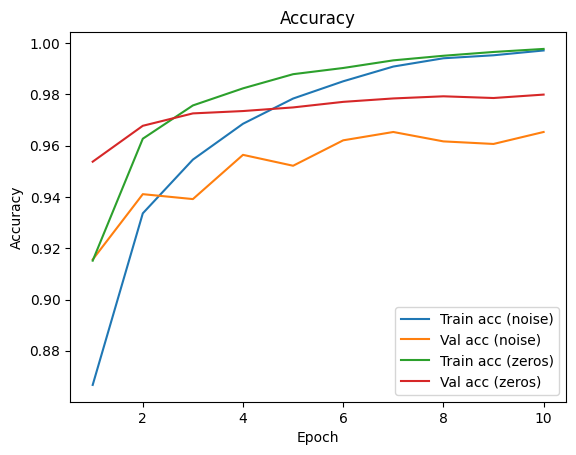

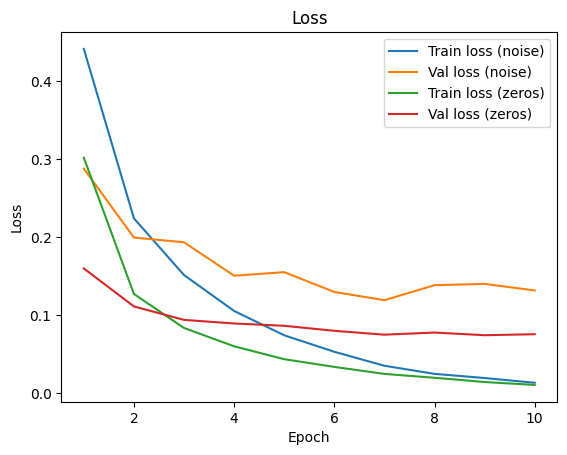

In [6]:
import matplotlib.pyplot as plt

def plot_histories(h_noise, h_zeros):
    hn = h_noise.history
    hz = h_zeros.history

    acc_key = "accuracy" 
    val_acc_key = "val_accuracy"

    epochs = range(1, len(hn["loss"]) + 1)

    plt.figure()
    plt.plot(epochs, hn[acc_key], label="Train acc (noise)")
    plt.plot(epochs, hn[val_acc_key], label="Val acc (noise)")
    plt.plot(epochs, hz[acc_key], label="Train acc (zeros)")
    plt.plot(epochs, hz[val_acc_key], label="Val acc (zeros)")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, hn["loss"], label="Train loss (noise)")
    plt.plot(epochs, hn["val_loss"], label="Val loss (noise)")
    plt.plot(epochs, hz["loss"], label="Train loss (zeros)")
    plt.plot(epochs, hz["val_loss"], label="Val loss (zeros)")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_histories(history_noise, history_zeros)

In [7]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1040 - loss: 2.3157 - val_accuracy: 0.1073 - val_loss: 2.3046
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1156 - loss: 2.2996 - val_accuracy: 0.1022 - val_loss: 2.3094
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1259 - loss: 2.2911 - val_accuracy: 0.1050 - val_loss: 2.3149
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1389 - loss: 2.2798 - val_accuracy: 0.1047 - val_loss: 2.3258
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1477 - loss: 2.2638 - val_accuracy: 0.0996 - val_loss: 2.3393
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1637 - loss: 2.2454 - val_accuracy: 0.0997 - val_loss: 2.3471
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1788 - loss: 2.2223 - val_accuracy: 0.0996 - val_loss: 2.3650
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1970 - loss: 2.1962 - val_accu

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9135 - loss: 0.2955 - val_accuracy: 0.9585 - val_loss: 0.1455
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9633 - loss: 0.1240 - val_accuracy: 0.9688 - val_loss: 0.1039
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.0806 - val_accuracy: 0.9747 - val_loss: 0.0874
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9827 - loss: 0.0585 - val_accuracy: 0.9753 - val_loss: 0.0847
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9875 - loss: 0.0429 - val_accuracy: 0.9758 - val_loss: 0.0796
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9901 - loss: 0.0326 - val_accuracy: 0.9752 - val_loss: 0.0783
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9932 - loss: 0.0243 - val_accuracy: 0.9792 - val_loss: 0.0736
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9949 - loss: 0.0183 - val_accuracy: 0.

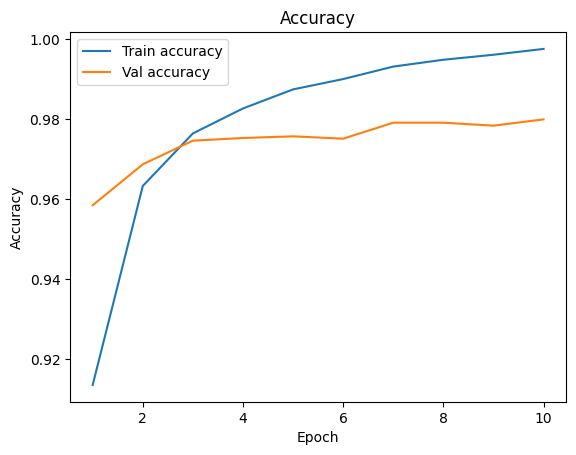

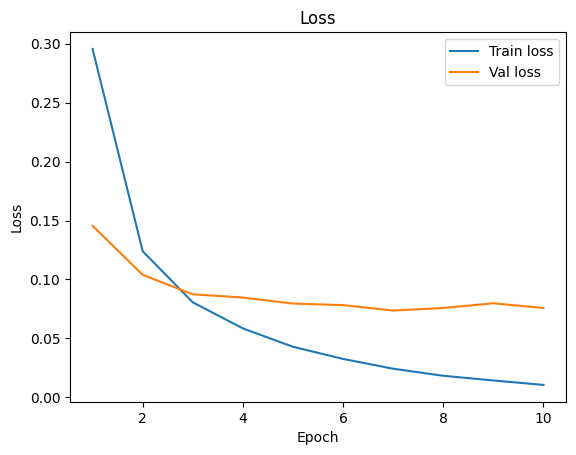

Test loss: 0.0700
Test accuracy: 0.9803


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.datasets import mnist


(train_images, train_labels), (test_images, test_labels) = mnist.load_data()


train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images  = test_images.reshape((10000, 28 * 28)).astype("float32") / 255


model = keras.Sequential([
    layers.Input(shape=(28 * 28,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax"),
])


model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)


h = history.history
epochs = range(1, len(h["loss"]) + 1)

plt.figure()
plt.plot(epochs, h["accuracy"], label="Train accuracy")
plt.plot(epochs, h["val_accuracy"], label="Val accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, h["loss"], label="Train loss")
plt.plot(epochs, h["val_loss"], label="Val loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")